# QUIC Traffic Classifier
### Exploratory Data Analysis + XGBoost Model

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FEATURES = [
    'packet_count', 'total_bytes', 'duration_s', 'bytes_per_sec',
    'mean_payload_len', 'std_payload_len', 'min_payload_len', 'max_payload_len',
    'mean_iat', 'std_iat', 'min_iat', 'max_iat',
    'burst_count', 'upload_ratio',
]

LABEL_COLORS = {
    'web':   '#4C72B0',
    'video': '#DD8452',
    'data':  '#55A868',
    'audio': '#C44E52',
}

print('imports ok')

imports ok


## 1. Load Data

In [18]:
all_raw = pd.read_csv('all_data.csv')

print("Class distribution before filtering:")
print(all_raw['label'].value_counts().to_string())
print()

MIN_SAMPLES = 10 
valid_classes = all_raw['label'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_SAMPLES].index

all_df = all_raw[all_raw['label'].isin(valid_classes)].copy()

print(f"Kept classes : {sorted(all_df['label'].unique())}")
print(f"Dropped      : {sorted(set(all_raw['label'].unique()) - set(all_df['label'].unique()))}")
print(f"Total rows   : {len(all_df)}")
print(f"Sources      : {sorted(all_df['source'].unique())}")



train_df, test_df = train_test_split(
    all_df,
    test_size=0.2,
    random_state=23,
    stratify=all_df['label']
)

print(f"\nTrain : {len(train_df)} rows")
print(f"Test  : {len(test_df)} rows")
print(f"\nTrain class distribution:")
print(train_df['label'].value_counts().to_string())
print(f"\nTest class distribution:")
print(test_df['label'].value_counts().to_string())

train_df.head()

Class distribution before filtering:
label
web      1094
data      181
video      85

Kept classes : ['data', 'video', 'web']
Dropped      : []
Total rows   : 1360
Sources      : ['archive_session1', 'archive_session2', 'archive_session3', 'archive_session4', 'archive_session5', 'browse_session1', 'browse_session2', 'browse_session3', 'browse_session4', 'browse_session5', 'cloudflare_20260517_143206', 'facebook_20260517_143544', 'gmail_20260517_143639', 'google_drive_20260517_143733', 'google_search_20260517_143017', 'instagram_20260517_143450', 'meet_session1', 'meet_session2', 'meet_session3', 'meet_session4', 'meet_session5', 'soundcloud_session1', 'soundcloud_session2', 'soundcloud_session3', 'soundcloud_session4', 'soundcloud_session5', 'twitch_20260517_143828', 'wikipedia_20260517_143111', 'youtube_session1', 'youtube_session2', 'youtube_session3', 'youtube_session4', 'youtube_session5', 'youtube_video_1_20260517_143300', 'youtube_video_2_20260517_143355']

Train : 1088 rows
Test

,source,window,flow_key,packet_count,total_bytes,duration_s,bytes_per_sec,mean_payload_len,std_payload_len,min_payload_len,max_payload_len,mean_iat,std_iat,min_iat,max_iat,burst_count,upload_ratio,label
505,meet_session2,0,cid:fd3296380caa80c0,12,3441,0.261,13178.220,286.750,448.200,39,1258,0.024,0.065,0.000,0.230,2,1.000,web
416,instagram_20260517_143450,0,5t:10.104.182.141:53394-57.144.168.141:443/17,11,6437,0.303,21219.650,585.180,533.780,49,1240,0.030,0.066,0.000,0.226,2,0.000,web
887,soundcloud_session3,0,5t:172.17.93.240:58814-172.217.24.162:443/17,196,237168,0.314,755741.010,1210.040,221.330,35,1258,0.002,0.005,0.000,0.040,1,0.000,web
261,gmail_20260517_143639,2,cid:e1f69688569ff5ce,261,12998,4.109,3162.970,49.800,63.910,40,624,0.016,0.103,0.000,1.326,3,1.000,data
4,archive_session1,0,5t:142.250.77.99:443-172.17.93.240:49339/17,44,48441,0.070,688873.260,1100.930,383.720,31,1258,0.002,0.003,0.000,0.020,1,0.000,web


## 2. Class Distribution

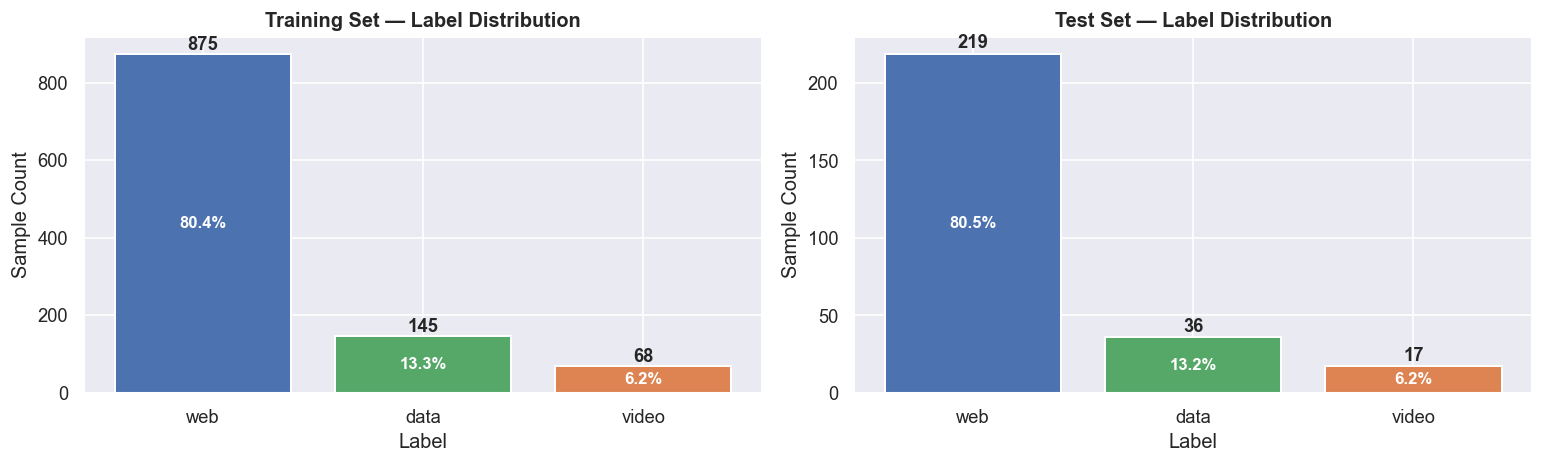


Class imbalance ratio (train):
label
web     12.900
data     2.100
video    1.000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Test Set']):
    counts = df['label'].value_counts()
    colors = [LABEL_COLORS.get(l, '#aaa') for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{title} — Label Distribution', fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Sample Count')
    # add percentage labels
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{pct:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plot_class_distribution.png', bbox_inches='tight')
plt.show()
print('\nClass imbalance ratio (train):')
counts = train_df['label'].value_counts()
print((counts / counts.min()).round(1).to_string())

## 3. Feature Distributions by Class

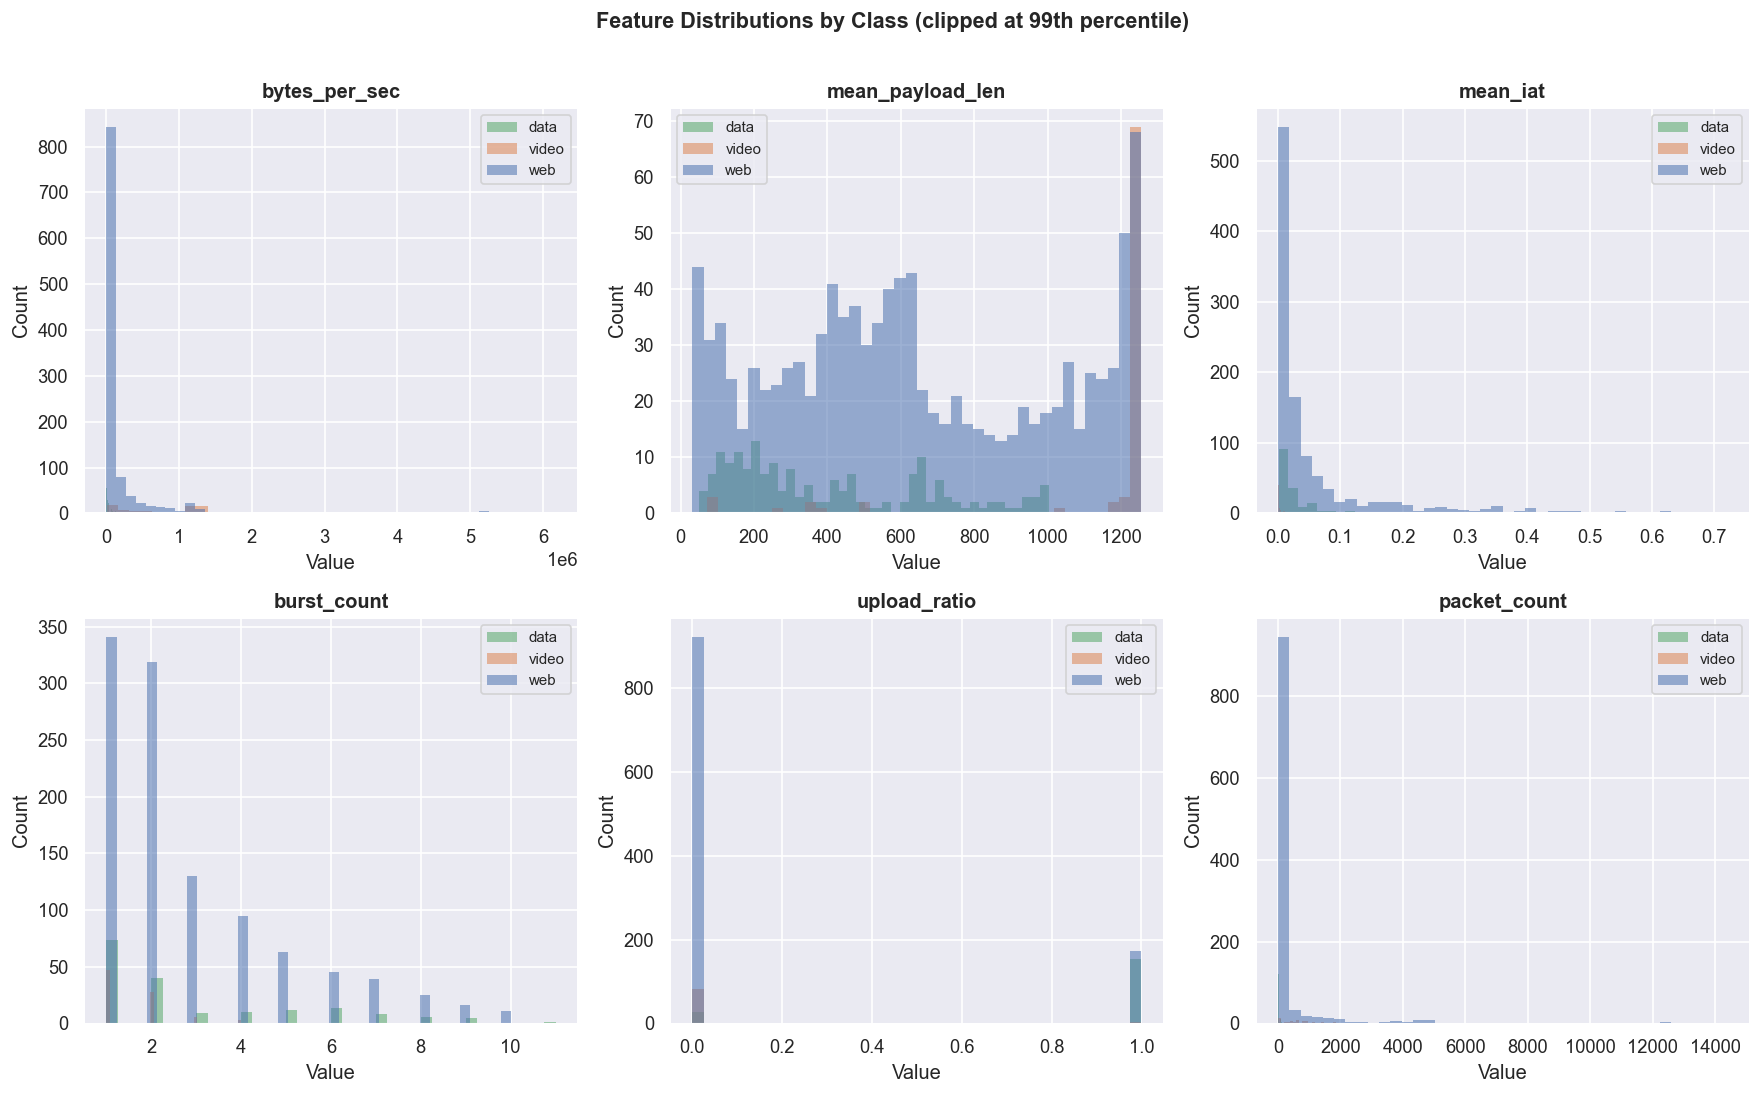

In [20]:
# most informative features for visual separation
key_features = ['bytes_per_sec', 'mean_payload_len', 'mean_iat', 'burst_count', 'upload_ratio', 'packet_count']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for label in sorted(all_df['label'].unique()):
        vals = all_df[all_df['label'] == label][feat].dropna()
        # clip extreme outliers for readability
        p99 = vals.quantile(0.99)
        vals = vals[vals <= p99]
        ax.hist(vals, bins=40, alpha=0.55, label=label,
                color=LABEL_COLORS.get(label, '#aaa'), edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Class (clipped at 99th percentile)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Boxplots — Median and Spread per Class

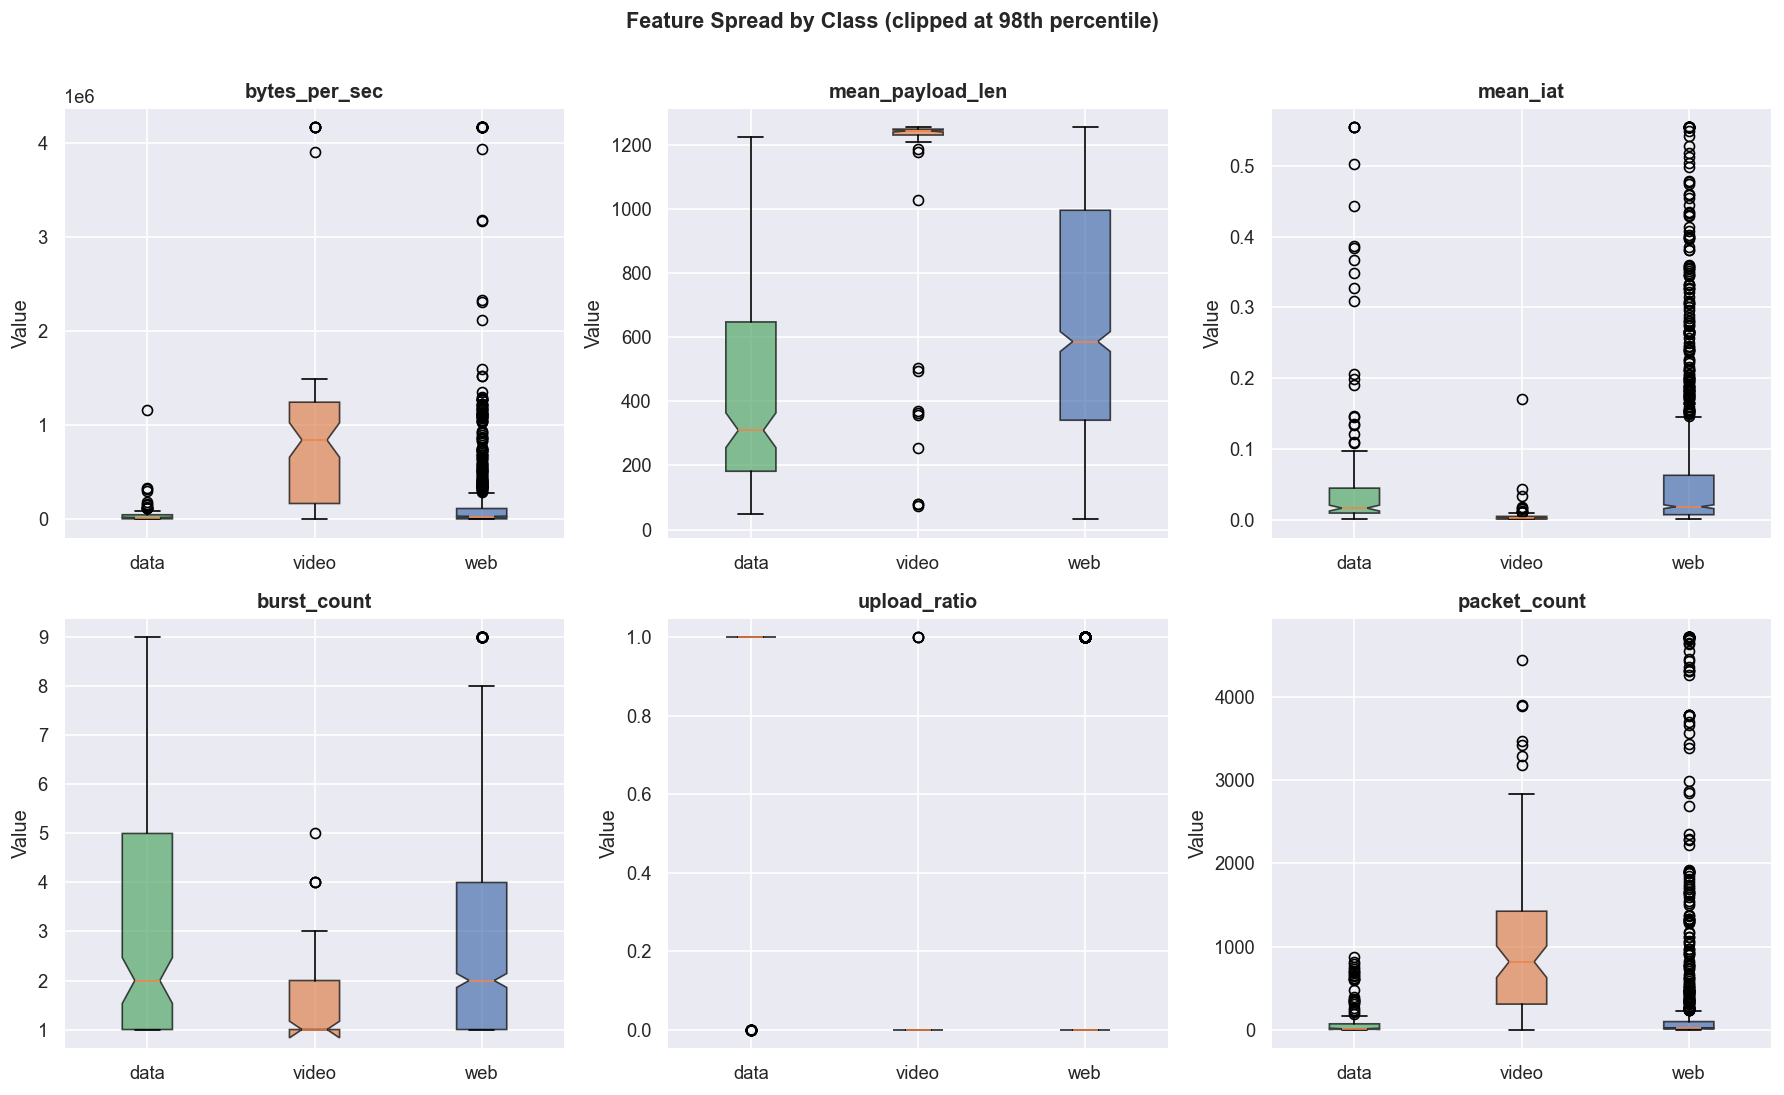

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    data_by_class = [
        all_df[all_df['label'] == label][feat].clip(
            upper=all_df[feat].quantile(0.98)
        ).dropna().values
        for label in sorted(all_df['label'].unique())
    ]
    labels_sorted = sorted(all_df['label'].unique())
    bp = ax.boxplot(data_by_class, labels=labels_sorted, patch_artist=True, notch=True)
    for patch, label in zip(bp['boxes'], labels_sorted):
        patch.set_facecolor(LABEL_COLORS.get(label, '#aaa'))
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Spread by Class (clipped at 98th percentile)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_boxplots.png', bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

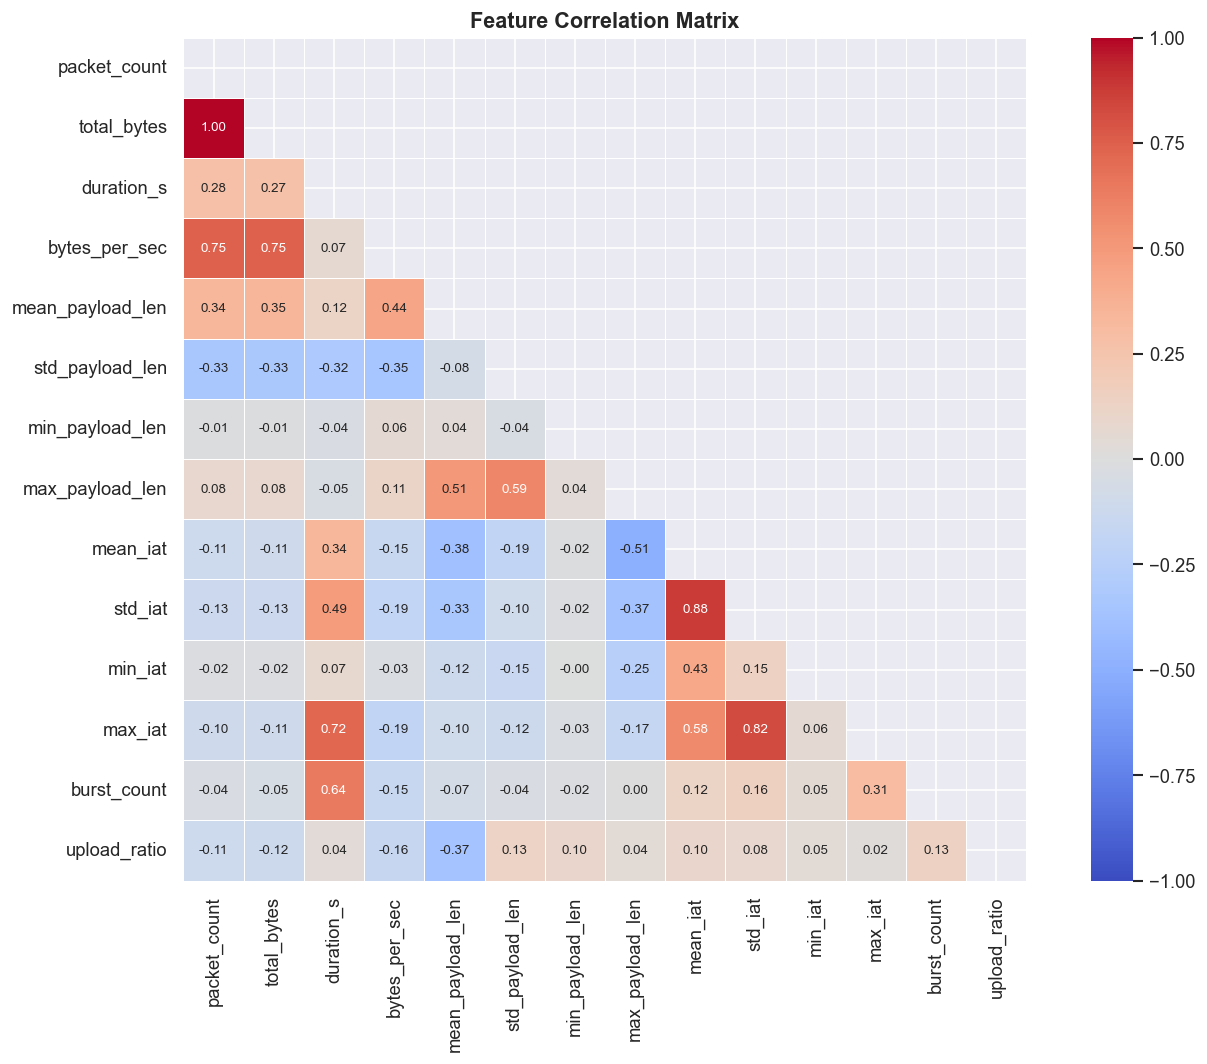

Highly correlated pairs (>0.85) — consider dropping one:
  total_bytes <-> packet_count : 0.999
  std_iat <-> mean_iat : 0.876


In [22]:
corr = all_df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()

# flag high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr:
    print('Highly correlated pairs (>0.85) — consider dropping one:')
    for a, b, v in high_corr:
        print(f'  {a} <-> {b} : {v:.3f}')
else:
    print('No feature pairs with correlation > 0.85')

## 7. Per-Class Feature Summary Stats

In [23]:
summary = all_df.groupby('label')[key_features].agg(['mean', 'median', 'std'])
summary.columns = ['_'.join(c) for c in summary.columns]
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
print('Per-class feature statistics:')
summary

Per-class feature statistics:


,bytes_per_sec_mean,bytes_per_sec_median,bytes_per_sec_std,mean_payload_len_mean,mean_payload_len_median,mean_payload_len_std,mean_iat_mean,mean_iat_median,mean_iat_std,burst_count_mean,burst_count_median,burst_count_std,upload_ratio_mean,upload_ratio_median,upload_ratio_std,packet_count_mean,packet_count_median,packet_count_std
label,,,,,,,,,,,,,,,,,,
data,42976.574,18713.440,98240.851,410.375,309.790,280.248,0.059,0.016,0.124,3.061,2.000,2.694,0.851,1.000,0.357,97.790,14.000,195.669
video,1059310.729,843283.860,1473165.727,1136.549,1242.230,300.361,0.006,0.001,0.019,1.624,1.000,0.859,0.035,0.000,0.186,1096.788,818.000,1069.002
web,257894.467,30042.255,820678.780,639.873,586.145,378.028,0.074,0.018,0.147,2.918,2.000,2.331,0.157,0.000,0.364,577.836,21.000,2443.034


## 8. Train XGBoost Model

In [24]:
# APPLY SMOTE TO TRAIN SET

from imblearn.over_sampling import SMOTE
from collections import Counter

# Encode labels first
le = LabelEncoder()
le.fit(train_df['label'])

print(f'Classes: {list(le.classes_)}')

# Original train/test split
X_train_og = train_df[FEATURES].values
y_train_og = le.transform(train_df['label'])

X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df['label'])

print("\nBefore SMOTE:")
for cls_id, count in sorted(Counter(y_train_og).items()):
    print(f"  {le.classes_[cls_id]}: {count}")

# Apply SMOTE only on training data
smote = SMOTE(
    sampling_strategy='auto',   # balance all minority classes
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_og, y_train_og)

print("\nAfter SMOTE:")
for cls_id, count in sorted(Counter(y_train_smote).items()):
    print(f"  {le.classes_[cls_id]}: {count}")

X_train = X_train_smote
y_train = y_train_smote

sample_weights = None

print(f"\nNew training shape: {X_train.shape}")

Classes: ['data', 'video', 'web']

Before SMOTE:
  data: 145
  video: 68
  web: 875

After SMOTE:
  data: 875
  video: 875
  web: 875

New training shape: (2625, 14)


In [25]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
)

model.fit(
    X_train, y_train,
    # sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)
print('\ntraining complete')

[0]	validation_0-mlogloss:1.03981	validation_1-mlogloss:1.04834
[50]	validation_0-mlogloss:0.17784	validation_1-mlogloss:0.34972
[100]	validation_0-mlogloss:0.07081	validation_1-mlogloss:0.28263
[150]	validation_0-mlogloss:0.03813	validation_1-mlogloss:0.27338
[200]	validation_0-mlogloss:0.02366	validation_1-mlogloss:0.27838
[250]	validation_0-mlogloss:0.01641	validation_1-mlogloss:0.28835
[299]	validation_0-mlogloss:0.01209	validation_1-mlogloss:0.29703

training complete


## 9. Training Curve

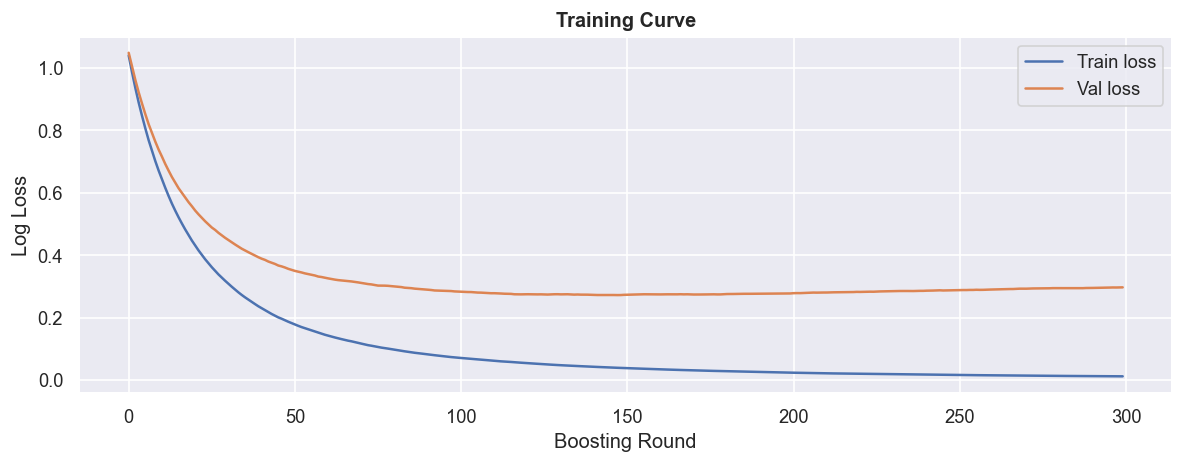

Final train loss : 0.0121
Final val loss   : 0.2970


In [26]:
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train loss', color='#4C72B0')
ax.plot(val_loss,   label='Val loss',   color='#DD8452')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('Training Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_training_curve.png', bbox_inches='tight')
plt.show()

print(f'Final train loss : {train_loss[-1]:.4f}')
print(f'Final val loss   : {val_loss[-1]:.4f}')

## 10. Evaluation

Classification Report:
              precision    recall  f1-score   support

        data       0.70      0.83      0.76        36
       video       0.74      0.82      0.78        17
         web       0.96      0.92      0.94       219

    accuracy                           0.90       272
   macro avg       0.80      0.86      0.82       272
weighted avg       0.91      0.90      0.90       272



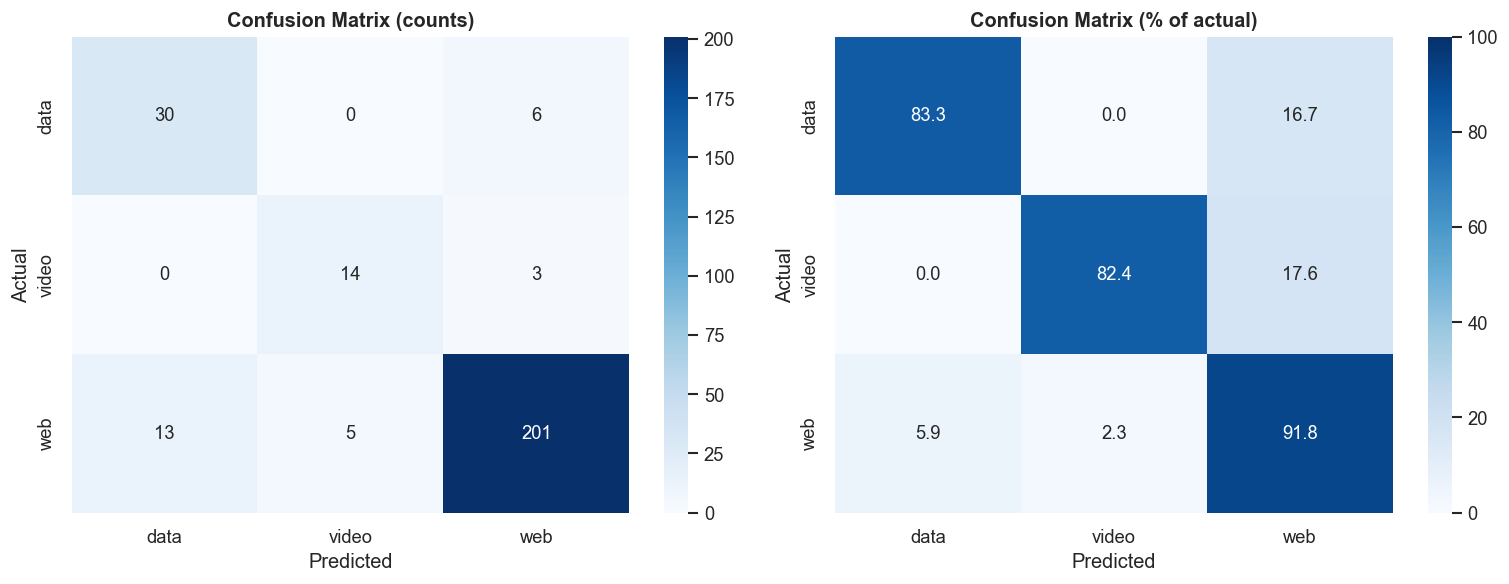

In [27]:
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# row-normalized percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix (% of actual)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 11. Feature Importance

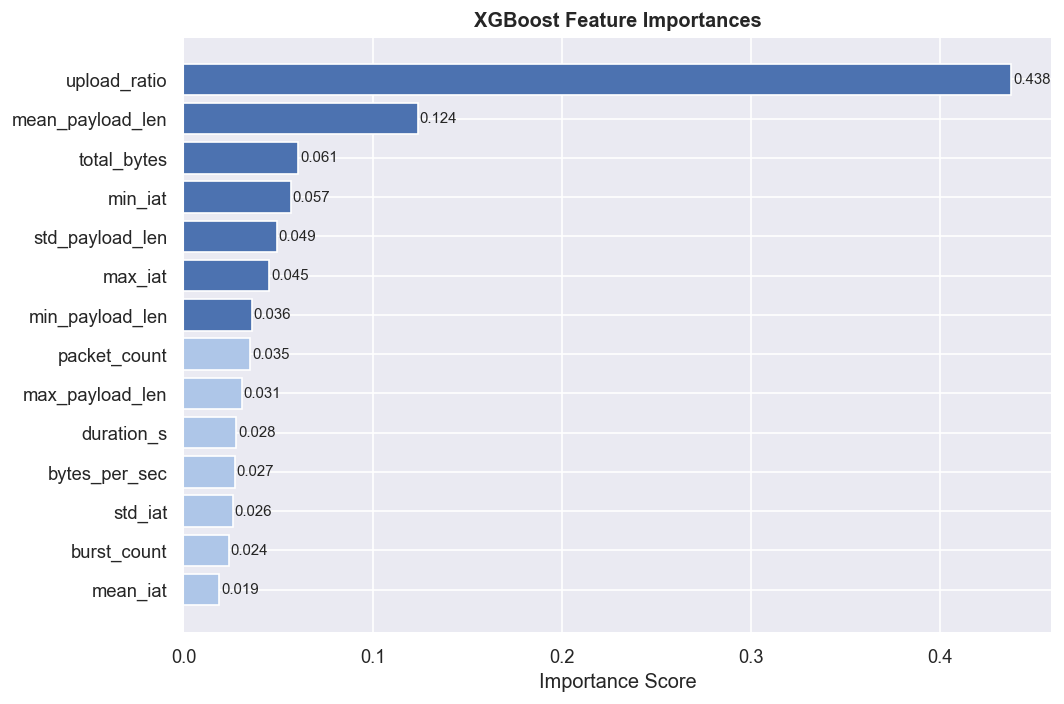

Top 5 features:
         feature  importance
    upload_ratio       0.438
mean_payload_len       0.124
     total_bytes       0.061
         min_iat       0.057
 std_payload_len       0.049


In [28]:
fi = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
fi = fi.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4C72B0' if v > fi['importance'].median() else '#aec6e8' for v in fi['importance']]
bars = ax.barh(fi['feature'], fi['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importances', fontweight='bold')

for bar, val in zip(bars, fi['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(fi.sort_values('importance', ascending=False).head(5).to_string(index=False))

## 12. Save Model

In [29]:
joblib.dump(model, 'model.pkl')
joblib.dump(le,    'label_encoder.pkl')
print('saved model.pkl and label_encoder.pkl')

saved model.pkl and label_encoder.pkl


In [30]:
# STRATIFIED 5-FOLD CROSS VALIDATION

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier

import numpy as np


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

acc_scores = []
macro_f1_scores = []

fold = 1

for train_idx, val_idx in skf.split(X_train_og, y_train_og):

    print(f'\n========== Fold {fold} ==========')

    X_train_fold = X_train_og[train_idx]
    y_train_fold = y_train_og[train_idx]

    X_val_fold = X_train_og[val_idx]
    y_val_fold = y_train_og[val_idx]

    # APPLY SMOTE HERE
    smote = SMOTE(random_state=42)

    X_train_fold, y_train_fold = smote.fit_resample(
        X_train_fold,
        y_train_fold
    )

    # model
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
    )

    # train
    model.fit(
        X_train_fold,
        y_train_fold,
        verbose=False
    )

    # predict
    y_pred = model.predict(X_val_fold)

    # metrics
    acc = accuracy_score(y_val_fold, y_pred)

    macro_f1 = f1_score(
        y_val_fold,
        y_pred,
        average='macro'
    )

    acc_scores.append(acc)
    macro_f1_scores.append(macro_f1)

    print(f'Accuracy : {acc:.4f}')
    print(f'Macro F1 : {macro_f1:.4f}')

    print('\nClassification Report:')
    print(classification_report(
        y_val_fold,
        y_pred,
        target_names=le.classes_
    ))

    fold += 1


========== Fold 1 ==========
Accuracy : 0.8853
Macro F1 : 0.7854

Classification Report:
              precision    recall  f1-score   support

        data       0.66      0.66      0.66        29
       video       0.83      0.71      0.77        14
         web       0.93      0.94      0.93       175

    accuracy                           0.89       218
   macro avg       0.81      0.77      0.79       218
weighted avg       0.88      0.89      0.88       218


========== Fold 2 ==========
Accuracy : 0.8991
Macro F1 : 0.8021

Classification Report:
              precision    recall  f1-score   support

        data       0.77      0.79      0.78        29
       video       0.61      0.79      0.69        14
         web       0.95      0.93      0.94       175

    accuracy                           0.90       218
   macro avg       0.78      0.83      0.80       218
weighted avg       0.91      0.90      0.90       218


========== Fold 3 ==========
Accuracy : 0.8670
Macro F1 :

In [31]:
# FINAL CROSS VALIDATION SUMMARY

print('\n========== CROSS VALIDATION RESULTS ==========')

print(f'Accuracy Scores : {acc_scores}')
print(f'Macro F1 Scores : {macro_f1_scores}')

print('\nAverage Accuracy : '
      f'{np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')

print('Average Macro F1: '
      f'{np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}')


========== CROSS VALIDATION RESULTS ==========
Accuracy Scores : [0.8853211009174312, 0.8990825688073395, 0.8669724770642202, 0.8940092165898618, 0.8847926267281107]
Macro F1 Scores : [0.7854071216140182, 0.8020971505772537, 0.7549836137839332, 0.807895115718245, 0.7927525366121856]

Average Accuracy : 0.8860 ± 0.0109
Average Macro F1: 0.7886 ± 0.0185
